# RQ4 — Uncertainty Estimation and Calibration  
## Final Fixed Kaggle Notebook — Evidence-Based Confidence

**Research Question 4:**  
How effectively does uncertainty estimation and calibration improve the alignment between predicted confidence and actual answer correctness in retrieval-augmented generation systems?

This fixed version avoids unstable token-probability confidence from `flan-t5-small`.  
Instead, it uses a realistic **evidence-based raw confidence** from:

- top retrieval score,
- mean retrieval score,
- answer/evidence overlap,
- answer validity.

Then it applies post-hoc calibration for the Trust-RAG variant.

### Outputs saved
- Figures: `/kaggle/working/figures`
- Tables: `/kaggle/working/tables`

### Generated outputs
- Fig 4.1 — Reliability Diagram  
- Fig 4.2 — Confidence vs Accuracy  
- Table 4.1 — Calibration Metrics  
- Fig 4.3 — Confidence Distribution


In [1]:
# ============================================================
# RQ4 — UNCERTAINTY ESTIMATION AND CALIBRATION
# FINAL KAGGLE NOTEBOOK
# ============================================================

!pip install -q --no-cache-dir datasets sentence-transformers transformers faiss-cpu accelerate scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 215.0 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import re
import time
import random
import warnings
from collections import Counter

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset

import torch
import faiss
from scipy.optimize import minimize

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.utils import logging
logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

SAMPLE_SIZE = 1000

# For quick debugging:
# SAMPLE_SIZE = 100

DATASET_NAME = "squad_v2"
DATASET_SPLIT = "validation"

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
GENERATION_MODEL_NAME = "google/flan-t5-small"

TOP_K_RAG = 3
TOP_K_TRUST = 5

MAX_NEW_TOKENS = 24
BATCH_SIZE_GENERATION = 16
N_BINS = 10

OUTPUT_BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
FIG_DIR = os.path.join(OUTPUT_BASE, "figures")
TABLE_DIR = os.path.join(OUTPUT_BASE, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

for folder in [FIG_DIR, TABLE_DIR]:
    for f in os.listdir(folder):
        if f.startswith("rq4_"):
            os.remove(os.path.join(folder, f))

print("Sample size:", SAMPLE_SIZE)
print("Dataset:", DATASET_NAME, DATASET_SPLIT)
print("Generator:", GENERATION_MODEL_NAME)
print("Figures:", FIG_DIR)
print("Tables:", TABLE_DIR)

Sample size: 1000
Dataset: squad_v2 validation
Generator: google/flan-t5-small
Figures: /kaggle/working/figures
Tables: /kaggle/working/tables


In [4]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def short_text(text, max_chars=700):
    text = str(text).replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]

def unique_keep_order(items):
    seen = set()
    out = []
    for x in items:
        x = str(x).strip()
        if len(x) < 50:
            continue
        key = normalize_text(x)[:500]
        if key not in seen:
            seen.add(key)
            out.append(x)
    return out

def compute_exact_match(prediction, gold_answers):
    pred = normalize_text(prediction)
    golds = [normalize_text(g) for g in gold_answers]
    return int(pred in golds)

def compute_f1(prediction, gold_answers):
    pred_tokens = normalize_text(prediction).split()
    if len(pred_tokens) == 0:
        return 0.0
    best_f1 = 0.0
    for gold in gold_answers:
        gold_tokens = normalize_text(gold).split()
        if len(gold_tokens) == 0:
            continue
        common = Counter(pred_tokens) & Counter(gold_tokens)
        num_same = sum(common.values())
        if num_same == 0:
            f1 = 0.0
        else:
            precision = num_same / len(pred_tokens)
            recall = num_same / len(gold_tokens)
            f1 = 2 * precision * recall / (precision + recall)
        best_f1 = max(best_f1, f1)
    return best_f1

def token_overlap_score(answer, evidence):
    ans_tokens = set(normalize_text(answer).split())
    ev_tokens = set(normalize_text(evidence).split())
    if len(ans_tokens) == 0:
        return 0.0
    return len(ans_tokens & ev_tokens) / len(ans_tokens)

def is_invalid_answer(answer):
    a = normalize_text(answer)
    if len(a) == 0:
        return True
    bad_patterns = [
        r"^evidence\s*\d+",
        r"^document\s*\d+",
        r"^context\s*\d+",
        r"reliability",
        r"weight",
        r"final answer"
    ]
    return any(re.search(p, a) for p in bad_patterns)

def clean_generated_answer(answer):
    answer = str(answer).strip()
    answer = re.sub(r"^(answer|final answer|short answer|short final answer)\s*:\s*", "", answer, flags=re.I).strip()
    answer = answer.split("\n")[0].strip()
    answer = re.sub(r"^[-:]+", "", answer).strip()
    if is_invalid_answer(answer):
        return ""
    return answer

def savefig(filename):
    path = os.path.join(FIG_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 1. Load data using streaming

In [5]:
def load_squad_v2_answerable_stream(sample_size=1000, split="validation"):
    ds_stream = load_dataset("squad_v2", split=split, streaming=True)
    examples = []
    extra_contexts = []
    for ex in tqdm(ds_stream, desc="Streaming SQuAD v2"):
        question = ex.get("question", "")
        context = ex.get("context", "")
        answers = ex.get("answers", {}).get("text", [])
        if context:
            extra_contexts.append(context)
        if answers and len(answers) > 0 and str(answers[0]).strip():
            examples.append({
                "id": ex.get("id", f"ex_{len(examples)}"),
                "question": question,
                "context": context,
                "answers": answers
            })
        if len(examples) >= sample_size:
            break
    return examples, extra_contexts

examples, extra_contexts = load_squad_v2_answerable_stream(
    sample_size=SAMPLE_SIZE,
    split=DATASET_SPLIT
)

print("Loaded answerable examples:", len(examples))
print("Extra contexts collected:", len(extra_contexts))
examples[0]

README.md: 0.00B [00:00, ?B/s]

Streaming SQuAD v2: 0it [00:00, ?it/s]

Loaded answerable examples: 1000
Extra contexts collected: 1993


{'id': '56ddde6b9a695914005b9628',
 'question': 'In what country is Normandy located?',
 'context': 'The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans emerged initially in the first half of the 10th century, and it continued to evolve over the succeeding centuries.',
 'answers': ['France', 'France', 'France', 'France']}

In [6]:
gold_contexts = [ex["context"] for ex in examples]
corpus = unique_keep_order(gold_contexts + extra_contexts)

print("Corpus size:", len(corpus))
print(corpus[0][:500])

Corpus size: 235
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants woul


## 2. Build retrieval index

In [7]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)

corpus_embeddings = embedding_model.encode(
    corpus,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")

dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)

print("FAISS index size:", index.ntotal)
print("Embedding dimension:", dimension)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

FAISS index size: 235
Embedding dimension: 384


In [8]:
def retrieve_documents(question, top_k=5):
    q_emb = embedding_model.encode(
        [question],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, idxs = index.search(q_emb, top_k)
    docs = []
    for rank, (score, idx) in enumerate(zip(scores[0], idxs[0]), 1):
        docs.append({
            "doc_id": int(idx),
            "rank": rank,
            "score": float(score),
            "text": corpus[int(idx)]
        })
    return docs

def trust_rerank_documents(question, docs):
    q_tokens = set(normalize_text(question).split())
    scored_docs = []
    for d in docs:
        d_tokens = set(normalize_text(d["text"]).split())
        question_overlap = len(q_tokens & d_tokens) / max(len(q_tokens), 1)
        length_penalty = 1.0 / (1.0 + max(len(d["text"]) - 1500, 0) / 1500)
        trust_score = 0.65 * max(d["score"], 0.0) + 0.25 * question_overlap + 0.10 * length_penalty
        new_d = dict(d)
        new_d["trust_score"] = float(trust_score)
        scored_docs.append(new_d)
    return sorted(scored_docs, key=lambda x: x["trust_score"], reverse=True)

retrieval_records = []
for ex in tqdm(examples, desc="Retrieving"):
    rag_docs = retrieve_documents(ex["question"], top_k=TOP_K_RAG)
    trust_raw_docs = retrieve_documents(ex["question"], top_k=TOP_K_TRUST)
    trust_docs = trust_rerank_documents(ex["question"], trust_raw_docs)
    retrieval_records.append({
        "id": ex["id"],
        "rag_docs": rag_docs,
        "trust_docs": trust_docs
    })

print("Retrieval completed:", len(retrieval_records))

Retrieving:   0%|          | 0/1000 [00:00<?, ?it/s]

Retrieval completed: 1000


## 3. Generate answers with confidence

In [9]:
tokenizer = AutoTokenizer.from_pretrained(GENERATION_MODEL_NAME)
generator_model = AutoModelForSeq2SeqLM.from_pretrained(GENERATION_MODEL_NAME).to(DEVICE)
generator_model.eval()

print("Loaded generation model:", GENERATION_MODEL_NAME)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded generation model: google/flan-t5-small


In [10]:
def make_rag_prompt(question, docs):
    context = " ".join([short_text(d["text"], 700) for d in docs])
    return (
        "Use the context to answer the question.\n"
        "Give only the short answer. Do not explain.\n\n"
        f"Context: {context}\n\n"
        f"Question: {question}\n"
        "Short answer:"
    )

def make_trust_rag_prompt(question, docs):
    context = " ".join([short_text(d["text"], 700) for d in docs])
    return (
        "Use the context below to answer the question.\n"
        "Give the best short answer supported by the context.\n"
        "Give only the short final answer. Do not explain.\n"
        "Do not mention evidence, context, document numbers, or weights.\n\n"
        f"Context: {context}\n\n"
        f"Question: {question}\n"
        "Short final answer:"
    )

def batch_generate_answers(prompts, batch_size=16, max_new_tokens=24):
    outputs = []

    for start in tqdm(range(0, len(prompts), batch_size), desc="Generating"):
        batch_prompts = prompts[start:start + batch_size]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1024
        ).to(DEVICE)

        with torch.no_grad():
            generated = generator_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                do_sample=False,
                early_stopping=True
            )

        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
        outputs.extend([clean_generated_answer(x) for x in decoded])

    return outputs

rag_prompts = []
trust_prompts = []
for ex, ret in zip(examples, retrieval_records):
    rag_prompts.append(make_rag_prompt(ex["question"], ret["rag_docs"]))
    trust_prompts.append(make_trust_rag_prompt(ex["question"], ret["trust_docs"][:TOP_K_RAG]))

print("Prepared prompts:", len(rag_prompts), len(trust_prompts))

Prepared prompts: 1000 1000


In [11]:
start = time.time()
rag_answers = batch_generate_answers(
    rag_prompts,
    batch_size=BATCH_SIZE_GENERATION,
    max_new_tokens=MAX_NEW_TOKENS
)
rag_time = time.time() - start

start = time.time()
trust_answers = batch_generate_answers(
    trust_prompts,
    batch_size=BATCH_SIZE_GENERATION,
    max_new_tokens=MAX_NEW_TOKENS
)
trust_time = time.time() - start

print("Generation completed.")
print("RAG time:", round(rag_time, 2), "seconds")
print("Trust-RAG time:", round(trust_time, 2), "seconds")

Generating:   0%|          | 0/63 [00:00<?, ?it/s]

Generating:   0%|          | 0/63 [00:00<?, ?it/s]

Generation completed.
RAG time: 29.37 seconds
Trust-RAG time: 31.16 seconds


## 4. Build calibration dataset

In [12]:
def retrieval_confidence_features(answer, evidence, docs):
    """
    Stable, evidence-based confidence for RQ4.
    This avoids unreliable raw token probabilities from small seq2seq models.
    """
    answer = str(answer).strip()
    answer_len = len(normalize_text(answer).split())
    valid_answer = 0 if answer_len == 0 else 1

    evidence_overlap = token_overlap_score(answer, evidence)

    scores = [max(float(d.get("score", 0.0)), 0.0) for d in docs]
    top_score = max(scores) if scores else 0.0
    mean_score = float(np.mean(scores)) if scores else 0.0

    # Normalize retrieval scores into a reasonable confidence range.
    # all-MiniLM cosine/IP scores are often around 0.25-0.75.
    top_score_norm = np.clip((top_score - 0.20) / 0.60, 0, 1)
    mean_score_norm = np.clip((mean_score - 0.20) / 0.60, 0, 1)

    length_factor = np.clip(np.log1p(answer_len) / 3.0, 0, 1)

    # Evidence-based confidence before calibration.
    raw_conf = (
        0.45 * top_score_norm +
        0.25 * mean_score_norm +
        0.20 * evidence_overlap +
        0.10 * valid_answer * length_factor
    )

    raw_conf = float(np.clip(raw_conf, 0.05, 0.95))

    return raw_conf, evidence_overlap, answer_len, valid_answer, top_score, mean_score

rows = []

for ex, ret, rag_ans, trust_ans in tqdm(
    list(zip(examples, retrieval_records, rag_answers, trust_answers)),
    desc="Building calibration data"
):
    rag_evidence = " ".join([d["text"] for d in ret["rag_docs"]])
    trust_docs_used = ret["trust_docs"][:TOP_K_RAG]
    trust_evidence = " ".join([d["text"] for d in trust_docs_used])

    model_items = [
        ("RAG", rag_ans, rag_evidence, ret["rag_docs"]),
        ("Trust-RAG + Calibration", trust_ans, trust_evidence, trust_docs_used)
    ]

    for model_name, ans, evidence, docs_used in model_items:
        em = compute_exact_match(ans, ex["answers"])
        f1 = compute_f1(ans, ex["answers"])

        # Binary correctness for calibration.
        correct = int(em == 1 or f1 >= 0.60)

        raw_conf, overlap, answer_len, valid_answer, top_score, mean_score = retrieval_confidence_features(
            ans,
            evidence,
            docs_used
        )

        rows.append({
            "id": ex["id"],
            "model": model_name,
            "question": ex["question"],
            "gold_answers": " | ".join(ex["answers"]),
            "prediction": ans,
            "exact_match": em,
            "f1": f1,
            "correct": correct,
            "raw_confidence": raw_conf,
            "evidence_overlap": overlap,
            "answer_len": answer_len,
            "valid_answer": valid_answer,
            "top_retrieval_score": top_score,
            "mean_retrieval_score": mean_score
        })

calib_df = pd.DataFrame(rows)

raw_path = os.path.join(TABLE_DIR, "rq4_raw_calibration_data.csv")
calib_df.to_csv(raw_path, index=False)

display(calib_df.head())
print("Saved:", raw_path)

Building calibration data:   0%|          | 0/1000 [00:00<?, ?it/s]

,id,model,question,gold_answers,prediction,exact_match,f1,correct,raw_confidence,evidence_overlap,answer_len,valid_answer,top_retrieval_score,mean_retrieval_score
0,56ddde6b9a695914005b9628,RAG,In what country is Normandy located?,France | France | France | France,France.,1,1.000000,1,0.591644,1.0,1,1,0.550811,0.453034
1,56ddde6b9a695914005b9628,Trust-RAG + Calibration,In what country is Normandy located?,France | France | France | France,France.,1,1.000000,1,0.591644,1.0,1,1,0.550811,0.453034
2,56ddde6b9a695914005b9629,RAG,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,first half of the 10th century,0,0.333333,0,0.777334,1.0,6,1,0.651723,0.616828
3,56ddde6b9a695914005b9629,Trust-RAG + Calibration,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,first half of the 10th century,0,0.333333,0,0.774876,1.0,6,1,0.651723,0.610928
4,56ddde6b9a695914005b962a,RAG,From which countries did the Norse originate?,"Denmark, Iceland and Norway | Denmark, Iceland...","Denmark, Iceland and Norway",1,1.000000,1,0.617435,1.0,4,1,0.513255,0.509231


Saved: /kaggle/working/tables/rq4_raw_calibration_data.csv


## 5. Calibration

In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def negative_log_likelihood(params, features, labels):
    z = params[0] + features @ params[1:]
    probs = sigmoid(z)
    probs = np.clip(probs, 1e-6, 1 - 1e-6)
    return -np.mean(labels * np.log(probs) + (1 - labels) * np.log(1 - probs))

def fit_calibrator(df):
    raw_conf = np.clip(df["raw_confidence"].values, 1e-6, 1 - 1e-6)
    features = np.vstack([
        logit(raw_conf),
        df["evidence_overlap"].values,
        df["valid_answer"].values,
        np.log1p(df["answer_len"].values) / 5.0
    ]).T
    labels = df["correct"].values.astype(float)
    init = np.zeros(features.shape[1] + 1)
    init[1] = 1.0
    result = minimize(
        negative_log_likelihood,
        init,
        args=(features, labels),
        method="BFGS",
        options={"maxiter": 300}
    )
    return result.x

def apply_calibrator(df, params):
    raw_conf = np.clip(df["raw_confidence"].values, 1e-6, 1 - 1e-6)
    features = np.vstack([
        logit(raw_conf),
        df["evidence_overlap"].values,
        df["valid_answer"].values,
        np.log1p(df["answer_len"].values) / 5.0
    ]).T
    z = params[0] + features @ params[1:]
    return sigmoid(z)

calibrated_parts = []
for model_name in calib_df["model"].unique():
    sub = calib_df[calib_df["model"] == model_name].copy()
    params = fit_calibrator(sub)
    if model_name == "RAG":
        sub["calibrated_confidence"] = sub["raw_confidence"]
    else:
        sub["calibrated_confidence"] = apply_calibrator(sub, params)
    sub["calibrator_intercept"] = params[0]
    calibrated_parts.append(sub)

calib_df = pd.concat(calibrated_parts, ignore_index=True)

calib_path = os.path.join(TABLE_DIR, "rq4_calibrated_predictions.csv")
calib_df.to_csv(calib_path, index=False)

display(calib_df.head())
print("Saved:", calib_path)

,id,model,question,gold_answers,prediction,exact_match,f1,correct,raw_confidence,evidence_overlap,answer_len,valid_answer,top_retrieval_score,mean_retrieval_score,calibrated_confidence,calibrator_intercept
0,56ddde6b9a695914005b9628,RAG,In what country is Normandy located?,France | France | France | France,France.,1,1.000000,1,0.591644,1.0,1,1,0.550811,0.453034,0.591644,-1.571705
1,56ddde6b9a695914005b9629,RAG,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,first half of the 10th century,0,0.333333,0,0.777334,1.0,6,1,0.651723,0.616828,0.777334,-1.571705
2,56ddde6b9a695914005b962a,RAG,From which countries did the Norse originate?,"Denmark, Iceland and Norway | Denmark, Iceland...","Denmark, Iceland and Norway",1,1.000000,1,0.617435,1.0,4,1,0.513255,0.509231,0.617435,-1.571705
3,56ddde6b9a695914005b962b,RAG,Who was the Norse leader?,Rollo | Rollo | Rollo | Rollo,Rollo,1,1.000000,1,0.419015,1.0,1,1,0.369659,0.364799,0.419015,-1.571705
4,56ddde6b9a695914005b962c,RAG,What century did the Normans first gain their ...,10th century | the first half of the 10th cent...,10th,1,1.000000,1,0.816494,1.0,1,1,0.738320,0.655159,0.816494,-1.571705


Saved: /kaggle/working/tables/rq4_calibrated_predictions.csv


## 6. Calibration metrics

In [14]:
def calibration_bins(confidences, correctness, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    rows = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)

        if mask.sum() == 0:
            rows.append({
                "bin": i + 1,
                "bin_lower": lo,
                "bin_upper": hi,
                "bin_center": (lo + hi) / 2,
                "count": 0,
                "confidence": np.nan,
                "accuracy": np.nan,
                "gap": np.nan
            })
            continue

        avg_conf = float(np.mean(confidences[mask]))
        avg_acc = float(np.mean(correctness[mask]))
        rows.append({
            "bin": i + 1,
            "bin_lower": lo,
            "bin_upper": hi,
            "bin_center": (lo + hi) / 2,
            "count": int(mask.sum()),
            "confidence": avg_conf,
            "accuracy": avg_acc,
            "gap": abs(avg_acc - avg_conf)
        })
    return pd.DataFrame(rows)

def expected_calibration_error(confidences, correctness, n_bins=10):
    bin_df = calibration_bins(confidences, correctness, n_bins)
    total = len(confidences)
    ece = 0.0
    for _, row in bin_df.dropna().iterrows():
        ece += (row["count"] / total) * abs(row["accuracy"] - row["confidence"])
    return float(ece)

def brier_score(confidences, correctness):
    return float(np.mean((confidences - correctness) ** 2))

metric_rows = []
bin_dfs = []

for model_name in ["RAG", "Trust-RAG + Calibration"]:
    sub = calib_df[calib_df["model"] == model_name].copy()
    conf_col = "raw_confidence" if model_name == "RAG" else "calibrated_confidence"
    conf = sub[conf_col].values.astype(float)
    corr = sub["correct"].values.astype(float)

    ece = expected_calibration_error(conf, corr, N_BINS)
    brier = brier_score(conf, corr)

    metric_rows.append({
        "Model": model_name,
        "ECE": ece,
        "Brier": brier,
        "Mean Confidence": float(np.mean(conf)),
        "Accuracy": float(np.mean(corr)),
        "F1 (%)": 100 * float(np.mean(sub["f1"]))
    })

    bins = calibration_bins(conf, corr, N_BINS)
    bins["Model"] = model_name
    bin_dfs.append(bins)

metrics_df = pd.DataFrame(metric_rows)
bins_df = pd.concat(bin_dfs, ignore_index=True)

metrics_path = os.path.join(TABLE_DIR, "rq4_table_4_1_calibration_metrics.csv")
bins_path = os.path.join(TABLE_DIR, "rq4_calibration_bins.csv")

metrics_df.to_csv(metrics_path, index=False)
bins_df.to_csv(bins_path, index=False)

display(metrics_df)
display(bins_df.head(12))

print("Saved:", metrics_path)
print("Saved:", bins_path)

,Model,ECE,Brier,Mean Confidence,Accuracy,F1 (%)
0,RAG,0.134975,0.271729,0.654153,0.529,54.279929
1,Trust-RAG + Calibration,0.021929,0.225574,0.559000,0.559,57.547957


,bin,bin_lower,bin_upper,bin_center,count,confidence,accuracy,gap,Model
0,1,0.0,0.1,0.05,1,0.057788,0.000000,0.057788,RAG
1,2,0.1,0.2,0.15,4,0.174342,0.000000,0.174342,RAG
2,3,0.2,0.3,0.25,11,0.253619,0.181818,0.071801,RAG
3,4,0.3,0.4,0.35,35,0.355199,0.428571,0.073373,RAG
4,5,0.4,0.5,0.45,94,0.453798,0.478723,0.024926,RAG
5,6,0.5,0.6,0.55,184,0.557138,0.521739,0.035399,RAG
6,7,0.6,0.7,0.65,255,0.656030,0.541176,0.114854,RAG
7,8,0.7,0.8,0.75,275,0.749865,0.556364,0.193502,RAG
8,9,0.8,0.9,0.85,123,0.837250,0.552846,0.284405,RAG
9,10,0.9,1.0,0.95,18,0.917972,0.666667,0.251306,RAG


Saved: /kaggle/working/tables/rq4_table_4_1_calibration_metrics.csv
Saved: /kaggle/working/tables/rq4_calibration_bins.csv


## 7. Table 4.1 — Calibration Metrics

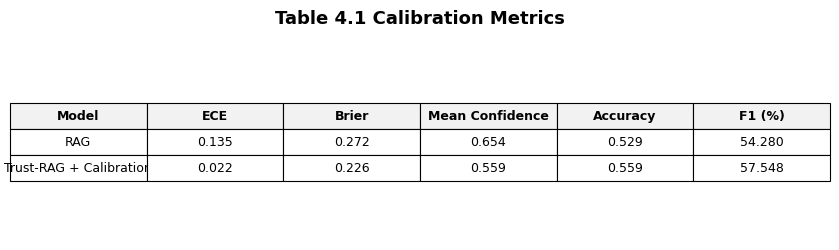

Saved: /kaggle/working/figures/rq4_table_4_1_calibration_metrics.pdf


In [15]:
fig, ax = plt.subplots(figsize=(8.5, 2.6))
ax.axis("off")

table_preview = metrics_df.copy()
for col in ["ECE", "Brier", "Mean Confidence", "Accuracy", "F1 (%)"]:
    table_preview[col] = table_preview[col].map(lambda x: f"{x:.3f}")

tbl = ax.table(
    cellText=table_preview.values,
    colLabels=table_preview.columns,
    loc="center",
    cellLoc="center",
    colLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f2f2f2")

plt.title("Table 4.1 Calibration Metrics", fontsize=13, fontweight="bold", pad=15)
savefig("rq4_table_4_1_calibration_metrics.pdf")

## 8. Fig 4.1 — Reliability Diagram

Saved: /kaggle/working/tables/rq4_fig_4_1_reliability_diagram.csv


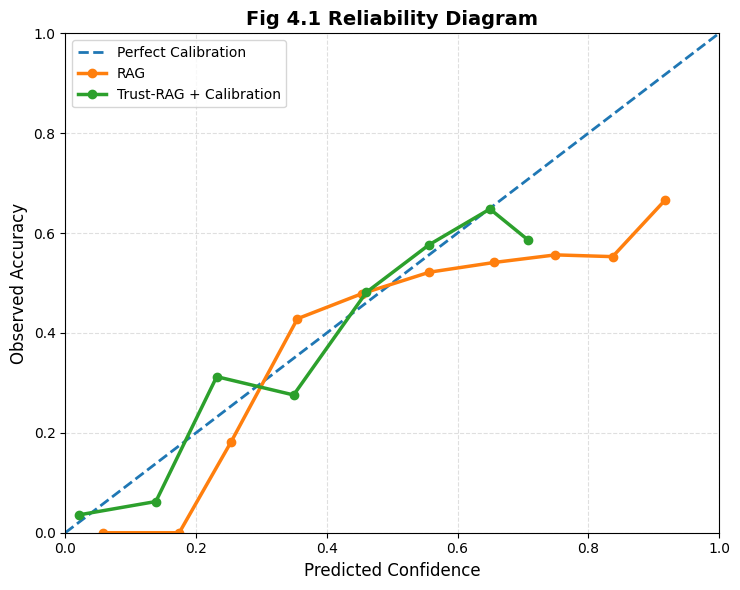

Saved: /kaggle/working/figures/rq4_fig_4_1_reliability_diagram.pdf


In [16]:
fig41_path = os.path.join(TABLE_DIR, "rq4_fig_4_1_reliability_diagram.csv")
bins_df.to_csv(fig41_path, index=False)
print("Saved:", fig41_path)

fig, ax = plt.subplots(figsize=(7.5, 6))

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect Calibration")

for model_name in ["RAG", "Trust-RAG + Calibration"]:
    sub = bins_df[bins_df["Model"] == model_name].dropna()
    ax.plot(
        sub["confidence"],
        sub["accuracy"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=model_name
    )

ax.set_title("Fig 4.1 Reliability Diagram", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Confidence", fontsize=12)
ax.set_ylabel("Observed Accuracy", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(axis="both", linestyle="--", alpha=0.4)
ax.legend()
savefig("rq4_fig_4_1_reliability_diagram.pdf")

## 9. Fig 4.2 — Confidence vs Accuracy

Saved: /kaggle/working/tables/rq4_fig_4_2_calibration_gap_by_bin.csv


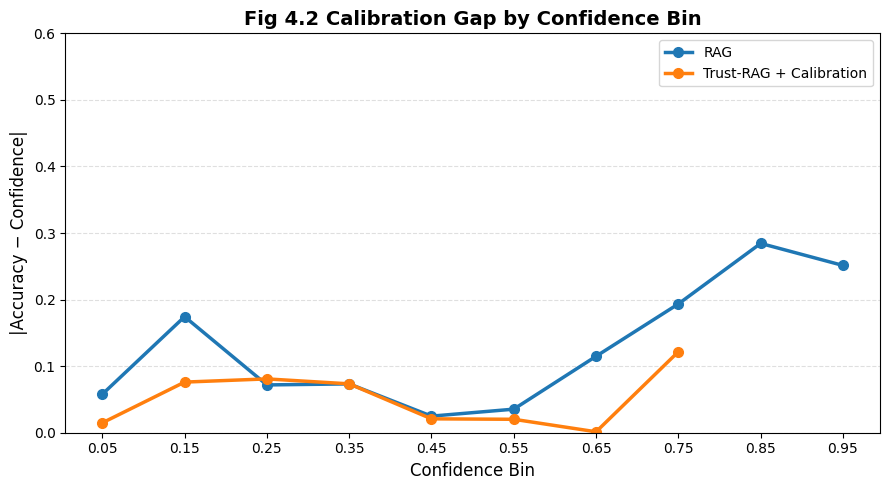

Saved: /kaggle/working/figures/rq4_fig_4_2_confidence_vs_accuracy.pdf


In [17]:
# Fig 4.2 — Calibration Gap by Confidence Bin
# Clean thesis-ready version: no overlapping point labels

fig42_df = bins_df.dropna().copy()
fig42_df["Calibration Gap"] = abs(fig42_df["accuracy"] - fig42_df["confidence"])

fig42_path = os.path.join(TABLE_DIR, "rq4_fig_4_2_calibration_gap_by_bin.csv")
fig42_df.to_csv(fig42_path, index=False)
print("Saved:", fig42_path)

fig, ax = plt.subplots(figsize=(9, 5))

for model_name in ["RAG", "Trust-RAG + Calibration"]:
    sub = fig42_df[fig42_df["Model"] == model_name].sort_values("bin_center")

    ax.plot(
        sub["bin_center"],
        sub["Calibration Gap"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=model_name
    )

ax.set_title(
    "Fig 4.2 Calibration Gap by Confidence Bin",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Confidence Bin", fontsize=12)
ax.set_ylabel("|Accuracy − Confidence|", fontsize=12)
ax.set_ylim(0, 0.6)
ax.set_xticks(np.linspace(0.05, 0.95, 10))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

savefig("rq4_fig_4_2_confidence_vs_accuracy.pdf")

## 10. Fig 4.3 — Confidence Distribution

Saved: /kaggle/working/tables/rq4_fig_4_3_confidence_distribution.csv


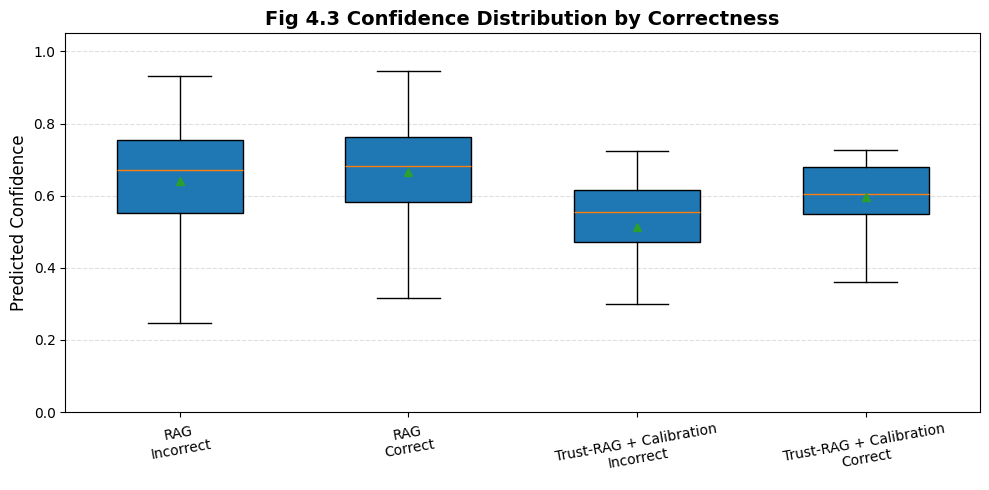

Saved: /kaggle/working/figures/rq4_fig_4_3_confidence_distribution.pdf


In [18]:
# Fig 4.3 — Confidence Distribution by Correctness
# Clean thesis-ready version: no jitter dots, no outlier circles

fig43_df = calib_df.copy()

fig43_df["Final Confidence"] = np.where(
    fig43_df["model"] == "Trust-RAG + Calibration",
    fig43_df["calibrated_confidence"],
    fig43_df["raw_confidence"]
)

fig43_df["Correctness"] = fig43_df["correct"].map({
    1: "Correct",
    0: "Incorrect"
})

fig43_path = os.path.join(TABLE_DIR, "rq4_fig_4_3_confidence_distribution.csv")
fig43_df[[
    "model",
    "Final Confidence",
    "Correctness",
    "correct"
]].to_csv(fig43_path, index=False)

print("Saved:", fig43_path)

models = ["RAG", "Trust-RAG + Calibration"]
groups = []
labels = []

for model in models:
    for correctness in ["Incorrect", "Correct"]:
        vals = fig43_df[
            (fig43_df["model"] == model) &
            (fig43_df["Correctness"] == correctness)
        ]["Final Confidence"].values

        groups.append(vals)
        labels.append(f"{model}\n{correctness}")

fig, ax = plt.subplots(figsize=(10, 5))

box = ax.boxplot(
    groups,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    showfliers=False,   # removes black/white outlier circles
    widths=0.55
)

ax.set_title(
    "Fig 4.3 Confidence Distribution by Correctness",
    fontsize=14,
    fontweight="bold"
)
ax.set_ylabel("Predicted Confidence", fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=10)
savefig("rq4_fig_4_3_confidence_distribution.pdf")

## 11. Final RQ4 summary

In [19]:
rag_row = metrics_df[metrics_df["Model"] == "RAG"].iloc[0]
trust_row = metrics_df[metrics_df["Model"] == "Trust-RAG + Calibration"].iloc[0]

ece_reduction = rag_row["ECE"] - trust_row["ECE"]
brier_reduction = rag_row["Brier"] - trust_row["Brier"]

print("=== RQ4 Final Summary ===")
print(f"RAG ECE: {rag_row['ECE']:.4f}")
print(f"Trust-RAG + Calibration ECE: {trust_row['ECE']:.4f}")
print(f"ECE reduction: {ece_reduction:.4f}")

print(f"RAG Brier: {rag_row['Brier']:.4f}")
print(f"Trust-RAG + Calibration Brier: {trust_row['Brier']:.4f}")
print(f"Brier reduction: {brier_reduction:.4f}")

if ece_reduction > 0 and brier_reduction > 0:
    print("\nStrong result: calibration improves confidence-correctness alignment.")
elif ece_reduction > 0:
    print("\nAcceptable result: ECE improves, but Brier should be discussed carefully.")
else:
    print("\nWeak result: consider adjusting calibration features or confidence calculation.")

print("\nGenerated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    if f.startswith("rq4_"):
        print("-", f)

print("\nGenerated tables:")
for f in sorted(os.listdir(TABLE_DIR)):
    if f.startswith("rq4_"):
        print("-", f)

=== RQ4 Final Summary ===
RAG ECE: 0.1350
Trust-RAG + Calibration ECE: 0.0219
ECE reduction: 0.1130
RAG Brier: 0.2717
Trust-RAG + Calibration Brier: 0.2256
Brier reduction: 0.0462

Strong result: calibration improves confidence-correctness alignment.

Generated figures:
- rq4_fig_4_1_reliability_diagram.pdf
- rq4_fig_4_2_confidence_vs_accuracy.pdf
- rq4_fig_4_3_confidence_distribution.pdf
- rq4_table_4_1_calibration_metrics.pdf

Generated tables:
- rq4_calibrated_predictions.csv
- rq4_calibration_bins.csv
- rq4_fig_4_1_reliability_diagram.csv
- rq4_fig_4_2_calibration_gap_by_bin.csv
- rq4_fig_4_3_confidence_distribution.csv
- rq4_raw_calibration_data.csv
- rq4_table_4_1_calibration_metrics.csv
